In [2]:
import torch
import braindecode
import mne
import numpy as np

print("PyTorch version:", torch.__version__)
print("Braindecode version:", braindecode.__version__)
print("MNE version:", mne.__version__)
print("NumPy version:", np.__version__)
print("\n环境 OK")

PyTorch version: 2.12.0
Braindecode version: 1.5.1
MNE version: 1.12.1
NumPy version: 2.4.6

环境 OK


In [4]:
from mne.datasets import eegbci
from mne.io import read_raw_edf

# 下载一个被试的数据（subject 1, run 4: 想象左手 vs 右手）
# 第一次跑会下载几 MB，下载完后会缓存到 ~/mne_data
fnames = eegbci.load_data(subjects=[1], runs=[4])
raw_fname = fnames[0]
print("数据文件位置:", raw_fname)

# 读取 EDF 格式的脑电数据
raw = read_raw_edf(raw_fname, preload=True)

# 打印数据基本信息
print("\n=== 数据信息 ===")
print(raw.info)
print("\n通道数:", len(raw.ch_names))
print("采样率:", raw.info['sfreq'], "Hz")
print("数据时长:", raw.times[-1], "秒")
print("数据形状 (通道数 × 时间点数):", raw.get_data().shape)

Download complete in 09s (2.5 MB)
数据文件位置: /Users/yihengli/mne_data/MNE-eegbci-data/files/eegmmidb/1.0.0/S001/S001R04.edf
Extracting EDF parameters from /Users/yihengli/mne_data/MNE-eegbci-data/files/eegmmidb/1.0.0/S001/S001R04.edf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 19999  =      0.000 ...   124.994 secs...

=== 数据信息 ===
<Info | 8 non-empty values
 bads: []
 ch_names: Fc5., Fc3., Fc1., Fcz., Fc2., Fc4., Fc6., C5.., C3.., C1.., ...
 chs: 64 EEG
 custom_ref_applied: False
 highpass: 0.0 Hz
 lowpass: 80.0 Hz
 meas_date: 2009-08-12 16:15:00 UTC
 nchan: 64
 projs: []
 sfreq: 160.0 Hz
 subject_info: <subject_info | his_id: X, sex: 0, last_name: X>
>

通道数: 64
采样率: 160.0 Hz
数据时长: 124.99375 秒
数据形状 (通道数 × 时间点数): (64, 20000)


Using matplotlib as 2D backend.


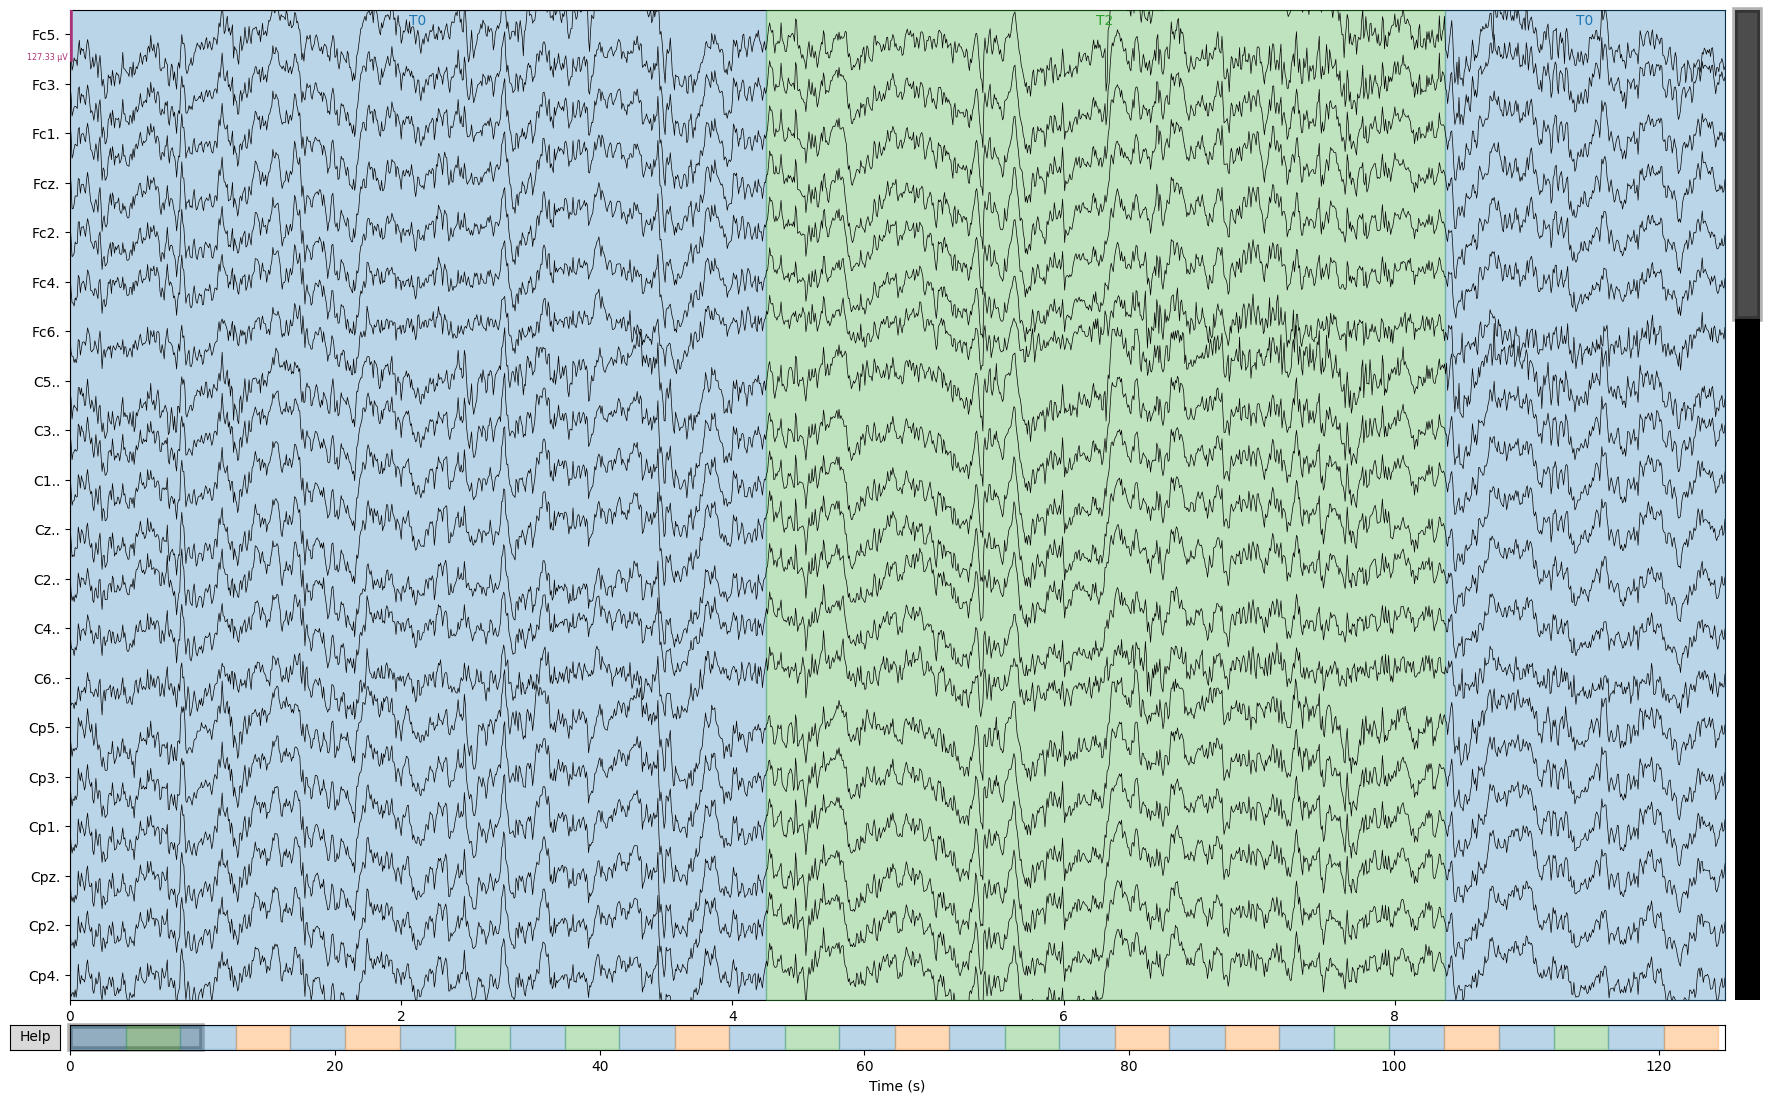

In [5]:
import matplotlib.pyplot as plt

# 画出前 10 秒的脑电信号
# scalings="auto" 让 MNE 自动选择 y 轴缩放
raw.plot(duration=10, n_channels=20, scalings="auto", show=True, block=False)
plt.show()

In [6]:
from mne import Epochs, pick_types, events_from_annotations

# Step 1: 从原始数据的 annotations 里提取事件
# annotations 是 EDF 文件里嵌入的"什么时候发生了什么"的标记
# event_id 是把字符串标签映射成数字（ML 标签需要是数字）
events, event_id = events_from_annotations(raw, event_id=dict(T1=2, T2=3))
print("事件总数:", len(events))
print("事件类别映射:", event_id)
print("\n前 5 个事件:")
print(events[:5])
print("(每行 = [样本号, 0, 事件类型])")

# Step 2: 选取所有 EEG 通道（排除非 EEG 通道，比如 EOG）
picks = pick_types(raw.info, meg=False, eeg=True, stim=False, eog=False, exclude="bads")
print("\n选用通道数:", len(picks))

# Step 3: 切 epochs
# tmin=-1.0 到 tmax=4.0 意思是：从事件标记前 1 秒切到事件后 4 秒
# 每个 epoch 时长 = 5 秒
# baseline=None 表示先不做 baseline correction
epochs = Epochs(
    raw,
    events,
    event_id,
    tmin=-1.0,
    tmax=4.0,
    proj=True,
    picks=picks,
    baseline=None,
    preload=True
)

print("\n=== Epochs 信息 ===")
print(epochs)
print("\nEpochs 数据形状:", epochs.get_data().shape)
print("(trial 数, 通道数, 时间点数)")
print("\n标签分布:")
print("  T1 (想象左手) trial 数:", len(epochs["T1"]))
print("  T2 (想象右手) trial 数:", len(epochs["T2"]))

Used Annotations descriptions: [np.str_('T1'), np.str_('T2')]


Task was destroyed but it is pending!
task: <Task pending name='Task-102' coro=<_async_in_context.<locals>.run_in_context() done, defined at /Users/yihengli/bci-project/venv/lib/python3.12/site-packages/ipykernel/utils.py:57> wait_for=<Task pending name='Task-103' coro=<Kernel.shell_main() running at /Users/yihengli/bci-project/venv/lib/python3.12/site-packages/ipykernel/kernelbase.py:597> cb=[Task.task_wakeup()]> cb=[ZMQStream._run_callback.<locals>._log_error() at /Users/yihengli/bci-project/venv/lib/python3.12/site-packages/zmq/eventloop/zmqstream.py:563]>
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/copy.py:252: RuntimeWarning: coroutine 'Kernel.shell_main' was never awaited
  args = (deepcopy(arg, memo) for arg in args)
Task was destroyed but it is pending!
task: <Task pending name='Task-103' coro=<Kernel.shell_main() running at /Users/yihengli/bci-project/venv/lib/python3.12/site-packages/ipykernel/kernelbase.py:597> cb=[Task.task_wakeup()]>


事件总数: 15
事件类别映射: {np.str_('T1'): 2, np.str_('T2'): 3}

前 5 个事件:
[[ 672    0    3]
 [2000    0    2]
 [3328    0    2]
 [4656    0    3]
 [5984    0    3]]
(每行 = [样本号, 0, 事件类型])

选用通道数: 64
Not setting metadata
15 matching events found
No baseline correction applied
0 projection items activated
Using data from preloaded Raw for 15 events and 801 original time points ...
0 bad epochs dropped

=== Epochs 信息 ===
<Epochs | 15 events (all good), -1 – 4 s (baseline off), ~5.9 MiB, data loaded,
 np.str_('T1'): 8
 np.str_('T2'): 7>

Epochs 数据形状: (15, 64, 801)
(trial 数, 通道数, 时间点数)

标签分布:
  T1 (想象左手) trial 数: 8
  T2 (想象右手) trial 数: 7


In [7]:
from mne.io import concatenate_raws

# 加载 subject 1 的所有"左手 vs 右手想象"runs
# runs 4, 8, 12 = 左/右手想象（PhysioNet 数据集规范）
runs = [4, 8, 12]
raw_fnames = eegbci.load_data(subjects=[1], runs=runs)

# 把多个 EDF 文件拼成一个 Raw 对象
raws = [read_raw_edf(f, preload=True) for f in raw_fnames]
raw_all = concatenate_raws(raws)

print("拼接后的数据时长:", raw_all.times[-1], "秒")
print("拼接后的数据 shape:", raw_all.get_data().shape)

# 重新提取事件 + 切 epochs
events, event_id = events_from_annotations(raw_all, event_id=dict(T1=2, T2=3))
picks = pick_types(raw_all.info, meg=False, eeg=True, stim=False, eog=False, exclude="bads")

epochs = Epochs(
    raw_all,
    events,
    event_id,
    tmin=-1.0,
    tmax=4.0,
    proj=True,
    picks=picks,
    baseline=None,
    preload=True
)

print("\n=== 拼接后 Epochs 信息 ===")
print("Epochs 数据形状:", epochs.get_data().shape)
print("  T1 (想象左手) trial 数:", len(epochs["T1"]))
print("  T2 (想象右手) trial 数:", len(epochs["T2"]))

Download complete in 22s (5.0 MB)
Extracting EDF parameters from /Users/yihengli/mne_data/MNE-eegbci-data/files/eegmmidb/1.0.0/S001/S001R04.edf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 19999  =      0.000 ...   124.994 secs...
Extracting EDF parameters from /Users/yihengli/mne_data/MNE-eegbci-data/files/eegmmidb/1.0.0/S001/S001R08.edf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 19999  =      0.000 ...   124.994 secs...
Extracting EDF parameters from /Users/yihengli/mne_data/MNE-eegbci-data/files/eegmmidb/1.0.0/S001/S001R12.edf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 19999  =      0.000 ...   124.994 secs...
拼接后的数据时长: 374.99375 秒
拼接后的数据 shape: (64, 60000)
Used Annotations descriptions: [np.str_('T1'), np.str_('T2')]
Not setting metadata
45 matching events found
No baseline correction applied
0 projection items activated
Using data from preloaded Raw for 45 events and 

In [8]:
import torch
import numpy as np
from torch.utils.data import TensorDataset, DataLoader
from braindecode.models import EEGNetv4

# ============ Step A: 滤波 ============
# 只保留 mu (8-13Hz) + beta (13-30Hz) 频段
epochs_filt = epochs.copy().filter(l_freq=8., h_freq=30.)
print("滤波完成: 8-30 Hz")

# ============ Step B: 拆 train / test ============
# 取 X (数据) 和 y (标签)
X = epochs_filt.get_data() * 1e6  # 单位从 V 转 μV (放大让模型更好训)
# 标签: T1=2 → 0 (左手), T2=3 → 1 (右手)
y = epochs_filt.events[:, -1] - 2

print(f"X shape: {X.shape}, y shape: {y.shape}")
print(f"标签分布: 左手={np.sum(y==0)}, 右手={np.sum(y==1)}")

# 用固定随机种子保证你每次跑结果一样
np.random.seed(42)
indices = np.random.permutation(len(X))
split = int(0.8 * len(X))
train_idx, test_idx = indices[:split], indices[split:]

X_train, y_train = X[train_idx], y[train_idx]
X_test, y_test = X[test_idx], y[test_idx]
print(f"训练集: {X_train.shape}, 测试集: {X_test.shape}")

# ============ Step C: 转 PyTorch tensor ============
X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.long)
X_test_t = torch.tensor(X_test, dtype=torch.float32)
y_test_t = torch.tensor(y_test, dtype=torch.long)

# DataLoader 帮你把数据分成 batch (一批 8 个 trial)
train_ds = TensorDataset(X_train_t, y_train_t)
train_loader = DataLoader(train_ds, batch_size=8, shuffle=True)

# ============ Step D: 创建 EEGNet 模型 ============
n_channels = X.shape[1]   # 64
n_times = X.shape[2]      # 801
n_classes = 2             # 左手 vs 右手

model = EEGNetv4(
    n_chans=n_channels,
    n_outputs=n_classes,
    n_times=n_times,
)
print(f"\n模型参数数量: {sum(p.numel() for p in model.parameters())}")

# ============ Step E: 训练 30 轮 ============
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
loss_fn = torch.nn.CrossEntropyLoss()

print("\n开始训练...")
for epoch_dl in range(30):
    model.train()
    total_loss = 0
    for xb, yb in train_loader:
        optimizer.zero_grad()
        out = model(xb)
        loss = loss_fn(out, yb)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    
    # 每 5 轮在 test 集上评估一次
    if (epoch_dl + 1) % 5 == 0:
        model.eval()
        with torch.no_grad():
            test_out = model(X_test_t)
            test_pred = test_out.argmax(dim=1)
            test_acc = (test_pred == y_test_t).float().mean().item()
            train_out = model(X_train_t)
            train_pred = train_out.argmax(dim=1)
            train_acc = (train_pred == y_train_t).float().mean().item()
        print(f"Epoch {epoch_dl+1:2d}/30 | train_loss={total_loss/len(train_loader):.3f} | train_acc={train_acc:.2f} | test_acc={test_acc:.2f}")

# ============ Step F: 最终评估 ============
model.eval()
with torch.no_grad():
    test_out = model(X_test_t)
    test_pred = test_out.argmax(dim=1)
    final_acc = (test_pred == y_test_t).float().mean().item()

print(f"\n========== 最终结果 ==========")
print(f"Test Accuracy: {final_acc:.3f} ({final_acc*100:.1f}%)")
print(f"Baseline (随机猜): 50%")
print(f"测试集真实标签: {y_test_t.tolist()}")
print(f"模型预测结果:   {test_pred.tolist()}")

Setting up band-pass filter from 8 - 30 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 8.00
- Lower transition bandwidth: 2.00 Hz (-6 dB cutoff frequency: 7.00 Hz)
- Upper passband edge: 30.00 Hz
- Upper transition bandwidth: 7.50 Hz (-6 dB cutoff frequency: 33.75 Hz)
- Filter length: 265 samples (1.656 s)

滤波完成: 8-30 Hz
X shape: (45, 64, 801), y shape: (45,)
标签分布: 左手=23, 右手=22
训练集: (36, 64, 801), 测试集: (9, 64, 801)

模型参数数量: 2930


<decorator-gen-494>:4: FutureWarning: NOTE: EEGNetv4() is a deprecated class. `EEGNetv4` was renamed to `EEGNet` in v1.12; this alias will be removed in v1.14..



开始训练...
Epoch  5/30 | train_loss=0.642 | train_acc=0.94 | test_acc=0.44
Epoch 10/30 | train_loss=0.533 | train_acc=0.94 | test_acc=0.78
Epoch 15/30 | train_loss=0.395 | train_acc=0.83 | test_acc=0.56
Epoch 20/30 | train_loss=0.334 | train_acc=1.00 | test_acc=0.56
Epoch 25/30 | train_loss=0.162 | train_acc=1.00 | test_acc=0.89
Epoch 30/30 | train_loss=0.099 | train_acc=1.00 | test_acc=0.67

========== 最终结果 ==========
Test Accuracy: 0.667 (66.7%)
Baseline (随机猜): 50%
测试集真实标签: [0, 1, 1, 1, 1, 0, 0, 0, 0]
模型预测结果:   [0, 0, 0, 1, 1, 0, 0, 0, 1]


In [9]:
import warnings
warnings.filterwarnings("ignore")

# 已知有问题的被试，跳过
EXCLUDE_SUBJECTS = {88, 89, 92, 100, 104}

all_X = []
all_y = []
failed_subjects = []

print("开始批量加载被试数据...")
print("=" * 60)

for subj in range(1, 51):  # subject 1 到 50
    if subj in EXCLUDE_SUBJECTS:
        print(f"  Subject {subj:3d}: 跳过（已知问题）")
        continue
    
    try:
        # 下载 + 加载 3 个运动想象 run
        raw_fnames = eegbci.load_data(subjects=[subj], runs=[4, 8, 12])
        raws = [read_raw_edf(f, preload=True, verbose="ERROR") for f in raw_fnames]
        raw_all = concatenate_raws(raws)
        
        # 切 epochs
        events, _ = events_from_annotations(raw_all, event_id=dict(T1=2, T2=3), verbose="ERROR")
        picks = pick_types(raw_all.info, meg=False, eeg=True, stim=False, eog=False, exclude="bads")
        
        epochs_s = Epochs(
            raw_all, events, dict(T1=2, T2=3),
            tmin=-1.0, tmax=4.0,
            proj=True, picks=picks,
            baseline=None, preload=True,
            verbose="ERROR"
        )
        
        # 滤波 8-30 Hz
        epochs_s.filter(l_freq=8., h_freq=30., verbose="ERROR")
        
        # 提取数据 + 标签
        X_s = epochs_s.get_data() * 1e6  # 转 μV
        y_s = epochs_s.events[:, -1] - 2  # T1->0, T2->1
        
        # 确认 shape 正确（有些被试通道数会异常）
        if X_s.shape[1] != 64 or X_s.shape[2] != 801:
            print(f"  Subject {subj:3d}: shape 异常 {X_s.shape}，跳过")
            failed_subjects.append(subj)
            continue
        
        all_X.append(X_s)
        all_y.append(y_s)
        print(f"  Subject {subj:3d}: ✓ {X_s.shape[0]} trials")
        
    except Exception as e:
        print(f"  Subject {subj:3d}: ✗ 失败 ({type(e).__name__})")
        failed_subjects.append(subj)

# 合并所有被试
X_all = np.concatenate(all_X, axis=0)
y_all = np.concatenate(all_y, axis=0)

print("=" * 60)
print(f"\n成功加载 {len(all_X)} 个被试")
print(f"失败被试: {failed_subjects}")
print(f"总数据 shape: {X_all.shape}")
print(f"总 trial 数: {X_all.shape[0]}")
print(f"标签分布: 左手={np.sum(y_all==0)}, 右手={np.sum(y_all==1)}")

开始批量加载被试数据...
  Subject   1: ✓ 45 trials


Download complete in 32s (7.3 MB)
  Subject   2: ✓ 45 trials


Download complete in 32s (7.4 MB)
  Subject   3: ✓ 45 trials


Download complete in 30s (7.3 MB)
  Subject   4: ✓ 45 trials


Download complete in 32s (7.3 MB)
  Subject   5: ✓ 45 trials


...

Download complete in 33s (7.4 MB)
  Subject  46: ✓ 45 trials


Download complete in 32s (7.3 MB)
  Subject  47: ✓ 45 trials


Download complete in 32s (7.3 MB)
  Subject  48: ✓ 45 trials


Download complete in 32s (7.3 MB)
  Subject  49: ✓ 45 trials


Download complete in 32s (7.3 MB)
  Subject  50: ✓ 45 trials

成功加载 50 个被试
失败被试: []
总数据 shape: (2245, 64, 801)
总 trial 数: 2245
标签分布: 左手=1132, 右手=1113


In [15]:
import torch
import torch.nn as nn
import numpy as np
from torch.utils.data import TensorDataset, DataLoader
from braindecode.models import EEGNet  # 用新 API
from sklearn.metrics import confusion_matrix

# ============ Step 1: train/val/test split (70/15/15) ============
np.random.seed(42)
n_total = len(X_all)
indices = np.random.permutation(n_total)

n_train = int(0.70 * n_total)
n_val = int(0.15 * n_total)

train_idx = indices[:n_train]
val_idx = indices[n_train:n_train+n_val]
test_idx = indices[n_train+n_val:]

X_train, y_train = X_all[train_idx], y_all[train_idx]
X_val, y_val = X_all[val_idx], y_all[val_idx]
X_test, y_test = X_all[test_idx], y_all[test_idx]

print(f"训练集: {X_train.shape} ({len(X_train)} trials)")
print(f"验证集: {X_val.shape} ({len(X_val)} trials)")
print(f"测试集: {X_test.shape} ({len(X_test)} trials)")

# ============ Step 2: 转 tensor + DataLoader ============
def to_tensor(X, y):
    return torch.tensor(X, dtype=torch.float32), torch.tensor(y, dtype=torch.long)

X_train_t, y_train_t = to_tensor(X_train, y_train)
X_val_t, y_val_t = to_tensor(X_val, y_val)
X_test_t, y_test_t = to_tensor(X_test, y_test)

train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=32, shuffle=True)
val_loader = DataLoader(TensorDataset(X_val_t, y_val_t), batch_size=64, shuffle=False)

# ============ Step 3: 创建模型 ============
model = EEGNet(
    n_chans=64,
    n_outputs=2,
    n_times=801,
    drop_prob=0.5,  # dropout 50% 防过拟合
)
print(f"\n模型参数数量: {sum(p.numel() for p in model.parameters())}")

# ============ Step 4: 训练 + Early Stopping ============
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
loss_fn = nn.CrossEntropyLoss()

def evaluate(model, X_t, y_t):
    """在给定数据上评估准确率"""
    model.eval()
    with torch.no_grad():
        out = model(X_t)
        pred = out.argmax(dim=1)
        acc = (pred == y_t).float().mean().item()
    return acc, pred

best_val_acc = 0
best_epoch = 0
patience = 10  # early stopping: 10 轮没提升就停
patience_counter = 0
best_model_state = None

print("\n开始训练...")
print("=" * 70)

for epoch_dl in range(100):  # 最多训 100 轮，但通常早停在 30-50
    model.train()
    total_loss = 0
    for xb, yb in train_loader:
        optimizer.zero_grad()
        out = model(xb)
        loss = loss_fn(out, yb)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    
    train_loss = total_loss / len(train_loader)
    
    # 每轮在 val 集上评估
    val_acc, _ = evaluate(model, X_val_t, y_val_t)
    
    # 早停判断
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_epoch = epoch_dl + 1
        patience_counter = 0
        # 保存最好的模型权重
        best_model_state = {k: v.clone() for k, v in model.state_dict().items()}
    else:
        patience_counter += 1
    
    # 每 5 轮打印一次
    if (epoch_dl + 1) % 5 == 0:
        train_acc, _ = evaluate(model, X_train_t, y_train_t)
        print(f"Epoch {epoch_dl+1:3d} | loss={train_loss:.3f} | train_acc={train_acc:.3f} | val_acc={val_acc:.3f} | best_val={best_val_acc:.3f}@{best_epoch}")
    
    if patience_counter >= patience:
        print(f"\nEarly stopping! Val acc 已经 {patience} 轮没提升")
        print(f"最佳模型在 epoch {best_epoch}, val_acc={best_val_acc:.3f}")
        break

# ============ Step 5: 用最佳模型在 test 集上评估 ============
model.load_state_dict(best_model_state)
test_acc, test_pred = evaluate(model, X_test_t, y_test_t)
train_acc, _ = evaluate(model, X_train_t, y_train_t)

print("\n" + "=" * 70)
print("=========== 最终结果 ===========")
print(f"训练集准确率: {train_acc:.3f}")
print(f"验证集准确率: {best_val_acc:.3f}")
print(f"测试集准确率: {test_acc:.3f} ({test_acc*100:.1f}%)")
print(f"对比 baseline (单被试): 0.667")
print(f"随机猜测 baseline:     0.500")

# 混淆矩阵
cm = confusion_matrix(y_test_t.numpy(), test_pred.numpy())
print(f"\n混淆矩阵:")
print(f"            预测左手  预测右手")
print(f"真实左手:    {cm[0,0]:5d}     {cm[0,1]:5d}")
print(f"真实右手:    {cm[1,0]:5d}     {cm[1,1]:5d}")

训练集: (1571, 64, 801) (1571 trials)
验证集: (336, 64, 801) (336 trials)
测试集: (338, 64, 801) (338 trials)

模型参数数量: 2930

开始训练...
Epoch   5 | loss=0.688 | train_acc=0.558 | val_acc=0.491 | best_val=0.491@5
Epoch  10 | loss=0.678 | train_acc=0.614 | val_acc=0.524 | best_val=0.542@9
Epoch  15 | loss=0.678 | train_acc=0.619 | val_acc=0.497 | best_val=0.542@9

Early stopping! Val acc 已经 10 轮没提升
最佳模型在 epoch 9, val_acc=0.542

=========== 最终结果 ===========
训练集准确率: 0.612
验证集准确率: 0.542
测试集准确率: 0.533 (53.3%)
对比 baseline (单被试): 0.667
随机猜测 baseline:     0.500

混淆矩阵:
            预测左手  预测右手
真实左手:      109        62
真实右手:       96        71


In [16]:
import copy

# ============ Step 1: 按被试切分 ============
# all_X 是 list of arrays，每个 array 是一个被试的数据
# all_y 也是 list of arrays，每个 array 是一个被试的标签
# 这两个 list 之前加载数据时就是按被试分开的，直接用

print(f"被试数量: {len(all_X)}")
print(f"每个被试 trial 数: {[len(x) for x in all_X[:5]]}...")
print(f"每个被试标签数: {[len(y) for y in all_y[:5]]}...")

# 选 subject 1 (列表第 0 个) 当 "新用户" (target subject)
target_idx = 0
X_target = all_X[target_idx]
y_target = all_y[target_idx]

# 其他 49 个被试 = pretrain pool
X_pretrain = np.concatenate([all_X[i] for i in range(len(all_X)) if i != target_idx], axis=0)
y_pretrain = np.concatenate([all_y[i] for i in range(len(all_y)) if i != target_idx], axis=0)

print(f"\nPretrain 池: {X_pretrain.shape} ({len(X_pretrain)} trials, 49 被试)")
print(f"Target 被试: {X_target.shape} ({len(X_target)} trials)")

# Target 被试再分 calibration / test
n_calib = 10
np.random.seed(42)
target_indices = np.random.permutation(len(X_target))
calib_idx = target_indices[:n_calib]
test_idx = target_indices[n_calib:]

X_calib, y_calib = X_target[calib_idx], y_target[calib_idx]
X_test_target, y_test_target = X_target[test_idx], y_target[test_idx]

print(f"  Calibration (用来 fine-tune): {X_calib.shape}")
print(f"  Test (评估真实效果):         {X_test_target.shape}")

# ============ Step 2: 用 49 个被试 pretrain ============
print("\n" + "=" * 70)
print("Stage 1: Pretrain on 49 subjects")
print("=" * 70)

n_pre = len(X_pretrain)
pre_idx = np.random.permutation(n_pre)
n_pre_train = int(0.85 * n_pre)
pre_train_idx = pre_idx[:n_pre_train]
pre_val_idx = pre_idx[n_pre_train:]

X_pre_train = torch.tensor(X_pretrain[pre_train_idx], dtype=torch.float32)
y_pre_train = torch.tensor(y_pretrain[pre_train_idx], dtype=torch.long)
X_pre_val = torch.tensor(X_pretrain[pre_val_idx], dtype=torch.float32)
y_pre_val = torch.tensor(y_pretrain[pre_val_idx], dtype=torch.long)

pretrain_loader = DataLoader(TensorDataset(X_pre_train, y_pre_train), batch_size=32, shuffle=True)

pretrain_model = EEGNet(n_chans=64, n_outputs=2, n_times=801, drop_prob=0.5)
optimizer = torch.optim.Adam(pretrain_model.parameters(), lr=1e-3, weight_decay=1e-4)

best_val = 0
best_state = None
patience_count = 0
PATIENCE = 8

for epoch in range(50):
    pretrain_model.train()
    total_loss = 0
    for xb, yb in pretrain_loader:
        optimizer.zero_grad()
        loss = loss_fn(pretrain_model(xb), yb)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    
    val_acc, _ = evaluate(pretrain_model, X_pre_val, y_pre_val)
    if val_acc > best_val:
        best_val = val_acc
        best_state = copy.deepcopy(pretrain_model.state_dict())
        patience_count = 0
    else:
        patience_count += 1
    
    if (epoch + 1) % 5 == 0:
        print(f"  Pretrain epoch {epoch+1:2d} | loss={total_loss/len(pretrain_loader):.3f} | val_acc={val_acc:.3f}")
    
    if patience_count >= PATIENCE:
        print(f"  Early stop @ epoch {epoch+1}, best val={best_val:.3f}")
        break

pretrain_model.load_state_dict(best_state)

# ============ Step 3: 直接用 pretrain 模型测 target（不 fine-tune）============
print("\n" + "=" * 70)
print("Stage 2a: Pretrained 模型直接用在 target 被试（不 fine-tune）")
print("=" * 70)

X_test_target_t = torch.tensor(X_test_target, dtype=torch.float32)
y_test_target_t = torch.tensor(y_test_target, dtype=torch.long)

acc_no_finetune, _ = evaluate(pretrain_model, X_test_target_t, y_test_target_t)
print(f"无 fine-tune 准确率: {acc_no_finetune:.3f} ({acc_no_finetune*100:.1f}%)")

# ============ Step 4: 在 target 被试 calib 数据上 fine-tune ============
print("\n" + "=" * 70)
print(f"Stage 2b: 用 target 被试 {n_calib} 个 trial fine-tune")
print("=" * 70)

finetune_model = EEGNet(n_chans=64, n_outputs=2, n_times=801, drop_prob=0.5)
finetune_model.load_state_dict(best_state)

X_calib_t = torch.tensor(X_calib, dtype=torch.float32)
y_calib_t = torch.tensor(y_calib, dtype=torch.long)

ft_optimizer = torch.optim.Adam(finetune_model.parameters(), lr=1e-4)

for ft_epoch in range(30):
    finetune_model.train()
    ft_optimizer.zero_grad()
    out = finetune_model(X_calib_t)
    loss = loss_fn(out, y_calib_t)
    loss.backward()
    ft_optimizer.step()
    
    if (ft_epoch + 1) % 5 == 0:
        test_acc, _ = evaluate(finetune_model, X_test_target_t, y_test_target_t)
        train_acc_calib, _ = evaluate(finetune_model, X_calib_t, y_calib_t)
        print(f"  FT epoch {ft_epoch+1:2d} | loss={loss.item():.3f} | calib_acc={train_acc_calib:.3f} | test_acc={test_acc:.3f}")

acc_with_finetune, _ = evaluate(finetune_model, X_test_target_t, y_test_target_t)

# ============ Step 5: 总结 ============
print("\n" + "=" * 70)
print("================= 三种方案对比 =================")
print(f"1. 单被试训练 (之前):                  66.7%")
print(f"2. 49 被试合训 → 直接用:              {acc_no_finetune*100:.1f}%")
print(f"3. 49 被试 pretrain + {n_calib} trial fine-tune: {acc_with_finetune*100:.1f}%")
print(f"   随机猜测 baseline:                  50.0%")

被试数量: 50
每个被试 trial 数: [45, 45, 45, 45, 45]...
每个被试标签数: [45, 45, 45, 45, 45]...

Pretrain 池: (2200, 64, 801) (2200 trials, 49 被试)
Target 被试: (45, 64, 801) (45 trials)
  Calibration (用来 fine-tune): (10, 64, 801)
  Test (评估真实效果):         (35, 64, 801)

Stage 1: Pretrain on 49 subjects
  Pretrain epoch  5 | loss=0.690 | val_acc=0.512
  Pretrain epoch 10 | loss=0.679 | val_acc=0.500
  Pretrain epoch 15 | loss=0.672 | val_acc=0.506
  Pretrain epoch 20 | loss=0.653 | val_acc=0.518
  Early stop @ epoch 22, best val=0.570

Stage 2a: Pretrained 模型直接用在 target 被试（不 fine-tune）
无 fine-tune 准确率: 0.486 (48.6%)

Stage 2b: 用 target 被试 10 个 trial fine-tune
  FT epoch  5 | loss=0.643 | calib_acc=0.600 | test_acc=0.486
  FT epoch 10 | loss=0.675 | calib_acc=0.600 | test_acc=0.486
  FT epoch 15 | loss=0.648 | calib_acc=0.700 | test_acc=0.486
  FT epoch 20 | loss=0.671 | calib_acc=0.700 | test_acc=0.486
  FT epoch 25 | loss=0.687 | calib_acc=0.700 | test_acc=0.457
  FT epoch 30 | loss=0.584 | calib_acc=0.70

In [17]:
# ============ Fine-tune 改进版：只调最后一层 ============
print("=" * 70)
print(f"Stage 3: 冻住前面所有层，只 fine-tune 最后一层")
print("=" * 70)

# 新建模型，加载 pretrain 权重
finetune_v2 = EEGNet(n_chans=64, n_outputs=2, n_times=801, drop_prob=0.5)
finetune_v2.load_state_dict(best_state)

# 关键改动 1: 冻住所有层
for param in finetune_v2.parameters():
    param.requires_grad = False

# 关键改动 2: 解冻最后一层（找最后那个 Linear 层）
# EEGNet 的最后一层叫 final_layer 或 classifier，我们打印出来看
print("\n模型结构（找最后一层）:")
for name, module in finetune_v2.named_modules():
    if len(list(module.children())) == 0:  # 只打印叶子节点
        print(f"  {name}: {type(module).__name__}")

# 找出最后一层并解冻
# Braindecode 的 EEGNet 最后一层通常叫 'final_layer' 或在 'classifier' 里
# 我们用通用方法：解冻最后一个 Linear 或 Conv 层
last_layer_name = None
for name, module in finetune_v2.named_modules():
    if isinstance(module, (nn.Linear, nn.Conv2d)):
        last_layer_name = name

print(f"\n解冻最后一层: {last_layer_name}")

# 解冻最后一层的参数
for name, param in finetune_v2.named_parameters():
    if name.startswith(last_layer_name):
        param.requires_grad = True
        print(f"  解冻: {name}, shape={tuple(param.shape)}")

# 计算可训练参数数量
trainable_params = sum(p.numel() for p in finetune_v2.parameters() if p.requires_grad)
total_params = sum(p.numel() for p in finetune_v2.parameters())
print(f"\n可训练参数: {trainable_params} / 总参数: {total_params}")
print(f"(之前 fine-tune 是 {total_params} 个参数都在调，现在只调 {trainable_params} 个)")

# 关键改动 3: optimizer 只优化可训练参数
ft_optimizer_v2 = torch.optim.Adam(
    filter(lambda p: p.requires_grad, finetune_v2.parameters()),
    lr=1e-3  # 因为参数少了，可以用大一点的 lr
)

print("\n开始 fine-tune（只调最后一层）...")
for ft_epoch in range(30):
    finetune_v2.train()
    ft_optimizer_v2.zero_grad()
    out = finetune_v2(X_calib_t)
    loss = loss_fn(out, y_calib_t)
    loss.backward()
    ft_optimizer_v2.step()
    
    if (ft_epoch + 1) % 5 == 0:
        test_acc, _ = evaluate(finetune_v2, X_test_target_t, y_test_target_t)
        train_acc_calib, _ = evaluate(finetune_v2, X_calib_t, y_calib_t)
        print(f"  FT epoch {ft_epoch+1:2d} | loss={loss.item():.3f} | calib_acc={train_acc_calib:.3f} | test_acc={test_acc:.3f}")

acc_v2, _ = evaluate(finetune_v2, X_test_target_t, y_test_target_t)

# ============ 最终四方案对比 ============
print("\n" + "=" * 70)
print("================= 四种方案对比 =================")
print(f"1. 单被试训练 (subject 1, 45 trial):              66.7%")
print(f"2. 49 被试合训 → 直接用:                          {acc_no_finetune*100:.1f}%")
print(f"3. 49 被试 pretrain + 10 trial 全模型 fine-tune:  {acc_with_finetune*100:.1f}%")
print(f"4. 49 被试 pretrain + 10 trial 只调最后一层:      {acc_v2*100:.1f}%  ← 新方案")
print(f"   随机猜测 baseline:                              50.0%")

Stage 3: 冻住前面所有层，只 fine-tune 最后一层

模型结构（找最后一层）:
  ensuredims: Ensure4d
  dimshuffle: Rearrange
  conv_temporal: Conv2d
  bnorm_temporal: BatchNorm2d
  conv_spatial.parametrizations.weight.0: MaxNormParametrize
  bnorm_1: BatchNorm2d
  elu_1: ELU
  pool_1: AvgPool2d
  drop_1: Dropout
  conv_separable_depth: Conv2d
  conv_separable_point: Conv2d
  bnorm_2: BatchNorm2d
  elu_2: ELU
  pool_2: AvgPool2d
  drop_2: Dropout
  final_layer.conv_classifier: Conv2d
  final_layer.permute_back: Rearrange
  final_layer.squeeze.squeeze: Rearrange

解冻最后一层: final_layer.conv_classifier
  解冻: final_layer.conv_classifier.weight, shape=(2, 16, 1, 25)
  解冻: final_layer.conv_classifier.bias, shape=(2,)

可训练参数: 802 / 总参数: 2930
(之前 fine-tune 是 2930 个参数都在调，现在只调 802 个)

开始 fine-tune（只调最后一层）...
  FT epoch  5 | loss=0.642 | calib_acc=0.700 | test_acc=0.514
  FT epoch 10 | loss=0.572 | calib_acc=0.700 | test_acc=0.400
  FT epoch 15 | loss=0.668 | calib_acc=0.800 | test_acc=0.343
  FT epoch 20 | loss=0.717 | calib_ac

In [18]:
# ============ 修 bug：按被试切，不按 trial 切 ============
# 之前的 bug：把所有 trial 混在一起随机切，同一个被试的 trial 同时出现在 train/val
# 修复：用 leave-subjects-out，整个被试要么全在 train，要么全在 val/test

# 50 个被试的切分（固定 seed 保证可复现）
np.random.seed(42)
subject_indices = np.random.permutation(50)

# Split: 40 train, 5 val, 5 test (按被试)
train_subjects = subject_indices[:40]   # 40 个被试用来训练
val_subjects   = subject_indices[40:45] # 5 个被试用来 early stopping
test_subjects  = subject_indices[45:]   # 5 个被试用来最终评估（模拟真实新用户）

print("被试切分（按被试，不按 trial）:")
print(f"  Train 被试 ({len(train_subjects)} 个): {sorted(train_subjects.tolist())}")
print(f"  Val   被试 ({len(val_subjects)} 个):  {sorted(val_subjects.tolist())}")
print(f"  Test  被试 ({len(test_subjects)} 个): {sorted(test_subjects.tolist())}")

def gather_subjects(subject_idx_list):
    """按被试索引收集数据"""
    Xs = [all_X[i] for i in subject_idx_list]
    ys = [all_y[i] for i in subject_idx_list]
    return np.concatenate(Xs, axis=0), np.concatenate(ys, axis=0)

X_train_clean, y_train_clean = gather_subjects(train_subjects)
X_val_clean, y_val_clean = gather_subjects(val_subjects)
X_test_clean, y_test_clean = gather_subjects(test_subjects)

print(f"\n数据 shape:")
print(f"  Train: {X_train_clean.shape}")
print(f"  Val:   {X_val_clean.shape}")
print(f"  Test:  {X_test_clean.shape}")

# 转 tensor
X_train_ct = torch.tensor(X_train_clean, dtype=torch.float32)
y_train_ct = torch.tensor(y_train_clean, dtype=torch.long)
X_val_ct = torch.tensor(X_val_clean, dtype=torch.float32)
y_val_ct = torch.tensor(y_val_clean, dtype=torch.long)
X_test_ct = torch.tensor(X_test_clean, dtype=torch.float32)
y_test_ct = torch.tensor(y_test_clean, dtype=torch.long)

train_loader_clean = DataLoader(
    TensorDataset(X_train_ct, y_train_ct),
    batch_size=32, shuffle=True
)

# ============ 重做方案 2：cross-subject 训练 + 在新被试上测 ============
print("\n" + "=" * 70)
print("方案 2 (修正版): 在 40 被试上训练 + 在 5 个 unseen 被试上测试")
print("=" * 70)

model_clean = EEGNet(n_chans=64, n_outputs=2, n_times=801, drop_prob=0.5)
optimizer = torch.optim.Adam(model_clean.parameters(), lr=1e-3, weight_decay=1e-4)

best_val_clean = 0
best_state_clean = None
patience_count = 0
PATIENCE = 10

for epoch in range(60):
    model_clean.train()
    total_loss = 0
    for xb, yb in train_loader_clean:
        optimizer.zero_grad()
        loss = loss_fn(model_clean(xb), yb)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    
    val_acc, _ = evaluate(model_clean, X_val_ct, y_val_ct)
    if val_acc > best_val_clean:
        best_val_clean = val_acc
        best_state_clean = copy.deepcopy(model_clean.state_dict())
        patience_count = 0
    else:
        patience_count += 1
    
    if (epoch + 1) % 5 == 0:
        train_acc, _ = evaluate(model_clean, X_train_ct, y_train_ct)
        print(f"  Epoch {epoch+1:2d} | loss={total_loss/len(train_loader_clean):.3f} | train={train_acc:.3f} | val={val_acc:.3f} | best_val={best_val_clean:.3f}")
    
    if patience_count >= PATIENCE:
        print(f"  Early stop @ epoch {epoch+1}, best val={best_val_clean:.3f}")
        break

model_clean.load_state_dict(best_state_clean)
test_acc_v2_clean, _ = evaluate(model_clean, X_test_ct, y_test_ct)

print(f"\n方案 2 (cross-subject, 干净版): test_acc = {test_acc_v2_clean:.3f} ({test_acc_v2_clean*100:.1f}%)")
print(f"  对比之前有 bug 的版本: 48.6%")

# ============ 方案 3 重做：在每个 test 被试上 fine-tune ============
print("\n" + "=" * 70)
print("方案 3 (修正版): 对每个 test 被试做 10-trial fine-tune (全模型)")
print("=" * 70)

n_calib = 10
results_v3_clean = []

for tsub_idx in test_subjects:
    # 取这个 test 被试的数据
    X_t = all_X[tsub_idx]
    y_t = all_y[tsub_idx]
    
    # 切 calib / test
    np.random.seed(42 + tsub_idx)
    perm = np.random.permutation(len(X_t))
    calib_idx = perm[:n_calib]
    test_idx_local = perm[n_calib:]
    
    X_calib = torch.tensor(X_t[calib_idx], dtype=torch.float32)
    y_calib = torch.tensor(y_t[calib_idx], dtype=torch.long)
    X_test_local = torch.tensor(X_t[test_idx_local], dtype=torch.float32)
    y_test_local = torch.tensor(y_t[test_idx_local], dtype=torch.long)
    
    # 拷贝 pretrain 模型，全模型 fine-tune
    ft_model = EEGNet(n_chans=64, n_outputs=2, n_times=801, drop_prob=0.5)
    ft_model.load_state_dict(best_state_clean)
    ft_opt = torch.optim.Adam(ft_model.parameters(), lr=1e-4)
    
    for ft_ep in range(30):
        ft_model.train()
        ft_opt.zero_grad()
        loss = loss_fn(ft_model(X_calib), y_calib)
        loss.backward()
        ft_opt.step()
    
    acc, _ = evaluate(ft_model, X_test_local, y_test_local)
    results_v3_clean.append(acc)
    print(f"  Subject {tsub_idx}: fine-tune test_acc = {acc:.3f}")

v3_mean = np.mean(results_v3_clean)
v3_std = np.std(results_v3_clean)
print(f"\n方案 3 (全模型 FT, 干净版): {v3_mean*100:.1f}% ± {v3_std*100:.1f}% (5 被试平均)")

# ============ 方案 4 重做：只调最后一层 ============
print("\n" + "=" * 70)
print("方案 4 (修正版): 对每个 test 被试只调最后一层")
print("=" * 70)

results_v4_clean = []

for tsub_idx in test_subjects:
    X_t = all_X[tsub_idx]
    y_t = all_y[tsub_idx]
    
    np.random.seed(42 + tsub_idx)
    perm = np.random.permutation(len(X_t))
    calib_idx = perm[:n_calib]
    test_idx_local = perm[n_calib:]
    
    X_calib = torch.tensor(X_t[calib_idx], dtype=torch.float32)
    y_calib = torch.tensor(y_t[calib_idx], dtype=torch.long)
    X_test_local = torch.tensor(X_t[test_idx_local], dtype=torch.float32)
    y_test_local = torch.tensor(y_t[test_idx_local], dtype=torch.long)
    
    ft_model = EEGNet(n_chans=64, n_outputs=2, n_times=801, drop_prob=0.5)
    ft_model.load_state_dict(best_state_clean)
    
    # 冻住所有层
    for p in ft_model.parameters():
        p.requires_grad = False
    # 解冻最后一层
    for name, p in ft_model.named_parameters():
        if name.startswith("final_layer"):
            p.requires_grad = True
    
    ft_opt = torch.optim.Adam(
        filter(lambda p: p.requires_grad, ft_model.parameters()),
        lr=1e-3
    )
    
    for ft_ep in range(30):
        ft_model.train()
        ft_opt.zero_grad()
        loss = loss_fn(ft_model(X_calib), y_calib)
        loss.backward()
        ft_opt.step()
    
    acc, _ = evaluate(ft_model, X_test_local, y_test_local)
    results_v4_clean.append(acc)
    print(f"  Subject {tsub_idx}: last-layer FT test_acc = {acc:.3f}")

v4_mean = np.mean(results_v4_clean)
v4_std = np.std(results_v4_clean)
print(f"\n方案 4 (只调最后一层, 干净版): {v4_mean*100:.1f}% ± {v4_std*100:.1f}% (5 被试平均)")

# ============ 干净版最终对比 ============
print("\n" + "=" * 70)
print("================ 干净版四方案最终对比 (按被试切分) ================")
print(f"方案 2: cross-subject 直接用:                {test_acc_v2_clean*100:.1f}%")
print(f"方案 3: 全模型 fine-tune (5 被试平均):       {v3_mean*100:.1f}% ± {v3_std*100:.1f}%")
print(f"方案 4: 只调最后一层 (5 被试平均):           {v4_mean*100:.1f}% ± {v4_std*100:.1f}%")
print(f"随机猜测 baseline:                           50.0%")
print(f"\n注意: 现在用 5 个 test 被试 ± std, 而不是单次跑")
print(f"这才是 cross-subject BCI 的真实表现")

被试切分（按被试，不按 trial）:
  Train 被试 (40 个): [0, 1, 2, 3, 4, 5, 6, 8, 9, 11, 12, 13, 15, 16, 17, 19, 21, 23, 24, 25, 26, 27, 29, 30, 31, 32, 33, 34, 35, 36, 37, 39, 40, 41, 43, 44, 45, 46, 47, 48]
  Val   被试 (5 个):  [10, 18, 20, 22, 49]
  Test  被试 (5 个): [7, 14, 28, 38, 42]

数据 shape:
  Train: (1795, 64, 801)
  Val:   (225, 64, 801)
  Test:  (225, 64, 801)

方案 2 (修正版): 在 40 被试上训练 + 在 5 个 unseen 被试上测试
  Epoch  5 | loss=0.688 | train=0.608 | val=0.542 | best_val=0.560
  Epoch 10 | loss=0.683 | train=0.628 | val=0.547 | best_val=0.560
  Early stop @ epoch 14, best val=0.560

方案 2 (cross-subject, 干净版): test_acc = 0.520 (52.0%)
  对比之前有 bug 的版本: 48.6%

方案 3 (修正版): 对每个 test 被试做 10-trial fine-tune (全模型)
  Subject 7: fine-tune test_acc = 0.600
  Subject 42: fine-tune test_acc = 0.514
  Subject 14: fine-tune test_acc = 0.486
  Subject 28: fine-tune test_acc = 0.457
  Subject 38: fine-tune test_acc = 0.543

方案 3 (全模型 FT, 干净版): 52.0% ± 4.9% (5 被试平均)

方案 4 (修正版): 对每个 test 被试只调最后一层
  Subject 7: last-layer